In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.pandas.set_option("display.max_columns",None)
df = pd.read_csv(r"EasyVisa.csv")
print(df.shape)

(25480, 12)


In [2]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [3]:
feature_with_na =[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in feature_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '%missing values')

In [4]:
df.duplicated().sum()

0

In [5]:
df.drop('case_id',axis=1,inplace=True)

## Feature Extraction

In [6]:
from datetime import date

todays_date = date.today()
current_year = todays_date.year

In [7]:
current_year

2025

In [8]:
df['company_age'] = current_year - df['yr_of_estab']

In [9]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


In [10]:
df.drop('yr_of_estab',axis=1,inplace=True)

### Type of feature

In [11]:
num_feature = [feature for feature in df.columns if df[feature].dtype!= 'O']
print(f"There has {len(num_feature)} numerical features {num_feature}")

There has 3 numerical features ['no_of_employees', 'prevailing_wage', 'company_age']


In [12]:
cat_feature = [feature for feature in df.columns if df[feature].dtype == 'O']
print(f"There has {len(cat_feature)} numerical features {cat_feature}")

There has 8 numerical features ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [14]:
dis_feature = [feature for feature in num_feature if len(df[feature].unique())<=25]
print(f"There has {len(dis_feature)} numerical features {dis_feature}")

There has 0 numerical features []


In [15]:
con_feature = [feature for feature in num_feature if feature not in dis_feature]
print(f"There has {len(con_feature)} numerical features {con_feature}")

There has 3 numerical features ['no_of_employees', 'prevailing_wage', 'company_age']


In [16]:
x = df.drop('case_status',axis=1)
y = df['case_status']

In [17]:
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

In [18]:
y = np.where(y=='Denied',0,1)

In [19]:
y

array([0, 1, 0, ..., 1, 1, 1])

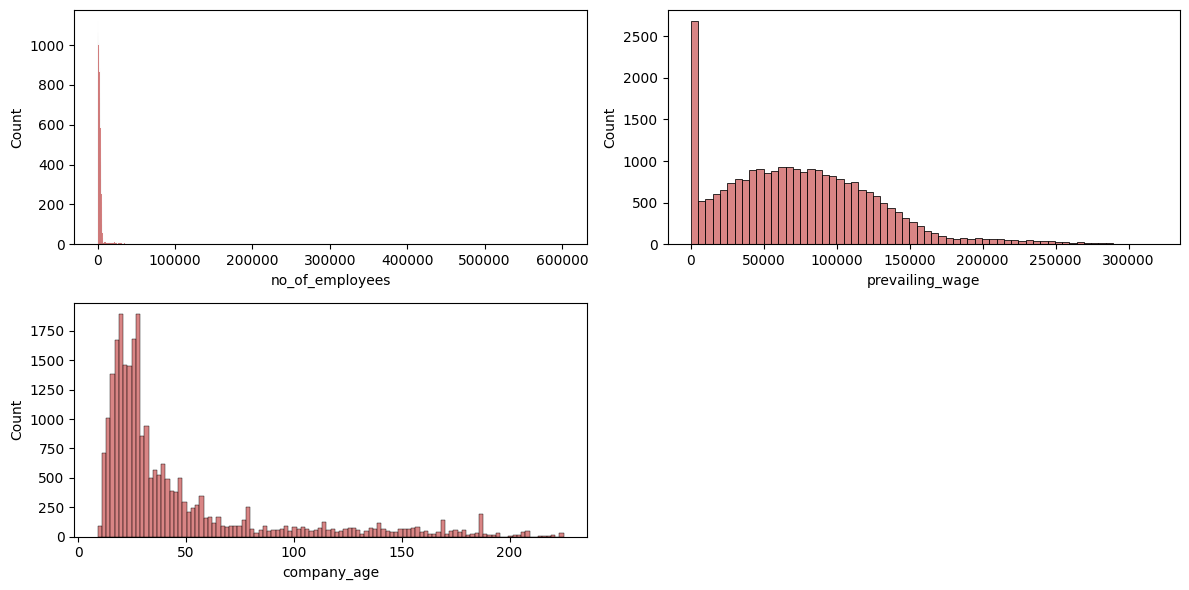

In [21]:
plt.figure(figsize=(12,6))
for i,col in enumerate(['no_of_employees', 'prevailing_wage', 'company_age']):
    plt.subplot(2,2,i+1)
    sns.histplot(x=x[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

#### Apply Power Transformer to Check if it can reduces the outliers

In [22]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_feature = ['no_of_employees', 'company_age']
x_copy = pt.fit_transform(x[transform_feature])

In [23]:
x_copy = pd.DataFrame(x_copy,columns=transform_feature)

In [24]:
x_copy

,no_of_employees,company_age
0,1.517300,-0.955551
1,0.030912,-0.467001
2,2.885076,-1.078363
3,-1.343550,1.630914
4,-0.432287,-0.738126
...,...,...
25475,0.079917,-1.078363
25476,0.235747,-0.842544
25477,-0.413885,1.550209
25478,-0.111949,1.684739


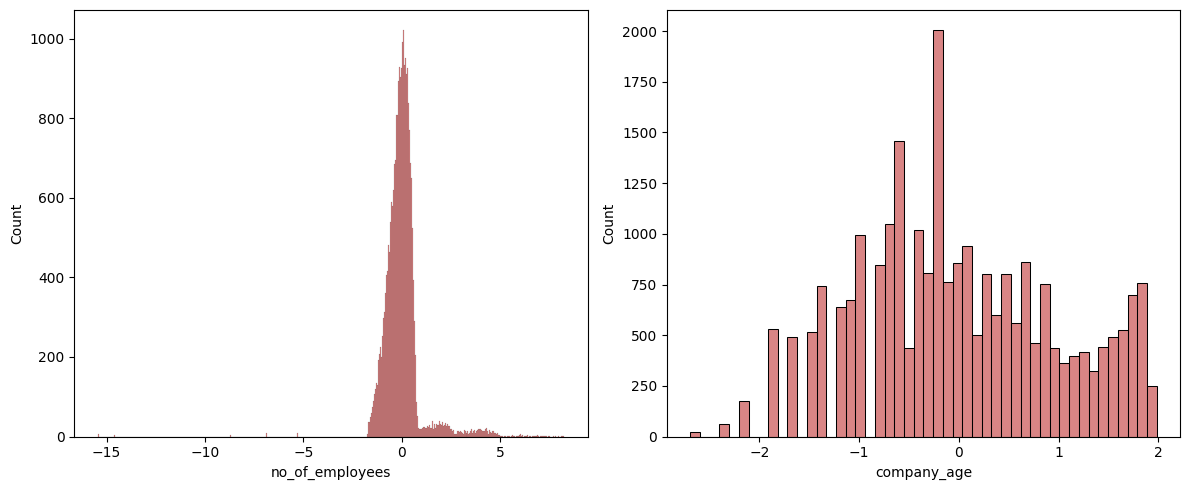

In [25]:
plt.figure(figsize=(12,5))
for i,col in enumerate(transform_feature):
    plt.subplot(1,2,i+1)
    sns.histplot(x=x_copy[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

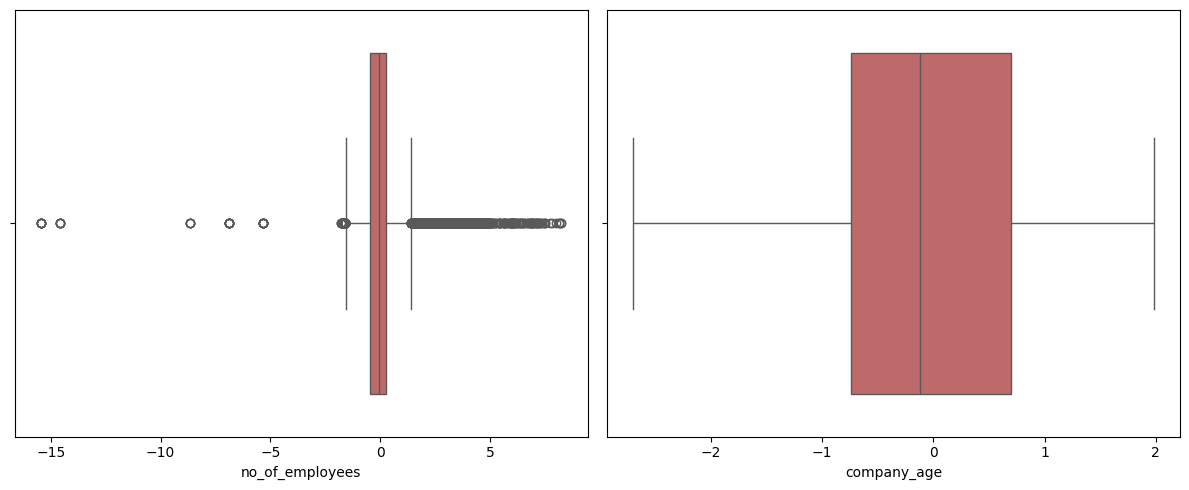

In [26]:
plt.figure(figsize=(12,5))
for i,col in enumerate(transform_feature):
    plt.subplot(1,2,i+1)
    sns.boxplot(x=x_copy[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [27]:
for feature in cat_feature:
    print(feature,':',df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


In [28]:
num_feature

['no_of_employees', 'prevailing_wage', 'company_age']

In [29]:
or_columns = ['education_of_employee','has_job_experience','requires_job_training','full_time_position']
oh_columns =['continent','region_of_employment','unit_of_wage']
transform_columns = ['no_of_employees','company_age']

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_transformer = StandardScaler()
oh_transfomer = OneHotEncoder()
ordinal_transformer = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer',PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transfomer,oh_columns),
        ('OrdinalEncoder',ordinal_transformer,or_columns),
        ("transformer",transform_pipe,transform_columns),
        ('StandardScaler',num_transformer,num_feature)
    ],remainder='passthrough'
)

In [30]:
x = preprocessor.fit_transform(x)

In [31]:
x

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]])

#### handle imbalanced data

In [32]:
from imblearn.combine import SMOTETomek, SMOTEENN

smt = SMOTEENN(random_state=42,sampling_strategy='minority')
x_res,y_res = smt.fit_resample(x,y)

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)


In [34]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [35]:
def evaluate_model(true,predicted):
    acc = accuracy_score(true,predicted)
    f1 = f1_score(true,predicted)
    precision = precision_score(true,predicted)
    recall = recall_score(true,predicted)
    roc_auc = roc_auc_score(true,predicted)
    return acc, f1, precision, recall, roc_auc

In [36]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoosting Classifier":CatBoostClassifier(verbose=False),
    "Support Vector Classifier": SVC(),
    AdaBoostClassifier: AdaBoostClassifier()
}

In [37]:
import pandas as pd 

In [38]:
import pandas as pd
def model_training(x,y,models):
    model_list = []
    accuracy_list = []
    auc = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(x_train,y_train)
 
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        model_train_accuracy,model_train_f1,model_train_precision,model_train_recall,model_train_rocauc_score = evaluate_model(y_train,y_train_pred)
        model_test_accuracy,model_test_f1,model_test_precision,model_test_recall,model_test_rocauc_score = evaluate_model(y_test,y_test_pred)

        print(list(models.keys())[i])
        model_list.append(list(models.keys())[i])
        
        print("Model Performance for training set:")
        print('Accuracy: {:.4f}'.format(model_train_accuracy))
        print('F1 score: {:.4f}'.format(model_train_f1))
        print('Precision: {:.4f}'.format(model_train_precision))
        print('Recall: {:.4f}'.format(model_train_recall))
        print('Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print("-"*35)

        print("Model Performance for test set:")
        print('Accuracy: {:.4f}'.format(model_test_accuracy))
        print('F1 score: {:.4f}'.format(model_test_f1))
        print('Precision: {:.4f}'.format(model_test_precision))
        print('Recall: {:.4f}'.format(model_test_recall))
        print('Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

        auc.append(model_test_rocauc_score)
        print("="*35)
        print("\n")

        accuracy_list.append(model_test_accuracy)
        report = pd.DataFrame(list(zip(model_list,accuracy_list)),columns=['Model Name','Accuracy']).sort_values(by=['Accuracy'],ascending=False).reset_index()

    return report

In [39]:
base_model_report = model_training(x=x_res,y=y_res,models=models)

Random Forest
Model Performance for training set:
Accuracy: 1.0000
F1 score: 1.0000
Precision: 1.0000
Recall: 1.0000
Roc Auc Score: 1.0000
-----------------------------------
Model Performance for test set:
Accuracy: 0.9466
F1 score: 0.9421
Precision: 0.9433
Recall: 0.9409
Roc Auc Score: 0.9462


Decision Tree
Model Performance for training set:
Accuracy: 1.0000
F1 score: 1.0000
Precision: 1.0000
Recall: 1.0000
Roc Auc Score: 1.0000
-----------------------------------
Model Performance for test set:
Accuracy: 0.9155
F1 score: 0.9087
Precision: 0.9064
Recall: 0.9110
Roc Auc Score: 0.9152


Gradient Boosting
Model Performance for training set:
Accuracy: 0.8881
F1 score: 0.8800
Precision: 0.8697
Recall: 0.8906
Roc Auc Score: 0.8883
-----------------------------------
Model Performance for test set:
Accuracy: 0.8823
F1 score: 0.8750
Precision: 0.8586
Recall: 0.8919
Roc Auc Score: 0.8830


Logistic Regression
Model Performance for training set:
Accuracy: 0.7380
F1 score: 0.7203
Precision: 0

In [40]:
base_model_report

,index,Model Name,Accuracy
0,0,Random Forest,0.946596
1,5,XGBClassifier,0.929577
2,4,K-Neighbors Classifier,0.926350
3,6,CatBoosting Classifier,0.925469
4,1,Decision Tree,0.915493
5,2,Gradient Boosting,0.882336
6,7,Support Vector Classifier,0.860915
7,8,<class 'sklearn.ensemble._weight_boosting.AdaB...,0.859448
8,3,Logistic Regression,0.735915


In [48]:
xgboost_params = {
    'max_depth': range(3,10,2),
    'min_child_weight': range(1,6,2)
}

rf_params = {
    'max_depth': [10, 12, None, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'n_estimators': [10,50,100,200]
}

knn_params = {
    "algorithm": ['auto','ball_tree','kd_tree','brute'],
    "weights": ['uniform','distance'],
    "n_neighbors": [3,4,5,7,9]
}

In [49]:
randomcv_models = [
    ("XGBoost", XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN",KNeighborsClassifier(),knn_params)
]

In [43]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=3,verbose=2,n_jobs=-1)
    random.fit(x_res,y_res)
    model_params[name] = random.best_params_

for model_name in model_params:
    print(f"----------------------- Best params for {model_name} -----------------------------------")
    print(model_params[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
----------------------- Best params for XGBoost -----------------------------------
{'min_child_weight': 1, 'max_depth': 9}
----------------------- Best params for RF -----------------------------------
{'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
----------------------- Best params for KNN -----------------------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [52]:
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_params['RF']),
    "KNeighbors Classifier": KNeighborsClassifier(**model_params['KNN']),
    "XGB Classifier": XGBClassifier(**model_params['XGBoost'],n_jobs=-1),

}
tuned_report = model_training(x=x_res, y=y_res, models=best_models)


Random Forest Classifier
Model Performance for training set:
Accuracy: 1.0000
F1 score: 1.0000
Precision: 1.0000
Recall: 1.0000
Roc Auc Score: 1.0000
-----------------------------------
Model Performance for test set:
Accuracy: 0.9516
F1 score: 0.9474
Precision: 0.9496
Recall: 0.9453
Roc Auc Score: 0.9511


KNeighbors Classifier
Model Performance for training set:
Accuracy: 1.0000
F1 score: 1.0000
Precision: 1.0000
Recall: 1.0000
Roc Auc Score: 1.0000
-----------------------------------
Model Performance for test set:
Accuracy: 0.9645
F1 score: 0.9611
Precision: 0.9727
Recall: 0.9498
Roc Auc Score: 0.9634


XGB Classifier
Model Performance for training set:
Accuracy: 0.9989
F1 score: 0.9988
Precision: 0.9998
Recall: 0.9978
Roc Auc Score: 0.9988
-----------------------------------
Model Performance for test set:
Accuracy: 0.9425
F1 score: 0.9379
Precision: 0.9349
Recall: 0.9409
Roc Auc Score: 0.9424




In [53]:
tuned_report

,index,Model Name,Accuracy
0,1,KNeighbors Classifier,0.964495
1,0,Random Forest Classifier,0.951585
2,2,XGB Classifier,0.942488


In [54]:
best_model = KNeighborsClassifier(**model_params['KNN'])
best_model = best_model.fit(x_train,y_train)
y_pred = best_model.predict(x_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("Final Model KNN")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

Final Model KNN
Accuracy Score value: 0.9645
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1835
           1       0.97      0.95      0.96      1573

    accuracy                           0.96      3408
   macro avg       0.97      0.96      0.96      3408
weighted avg       0.96      0.96      0.96      3408



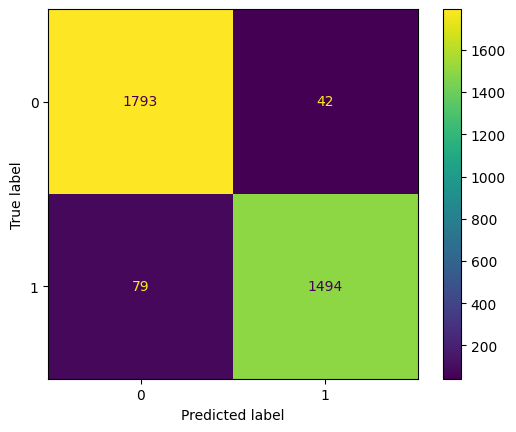

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model,x_test,y_test)


## Best Model is K-Nearest Neighbor(KNN) with Accuracy 96.99%